<a href="https://colab.research.google.com/github/Sukriti-124/aqua-safe/blob/main/aqua_safe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting up Dataset

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sukritisrivastava12","key":"30fa8b940f2a1c0ac8876a0d01eca613"}'}

In [3]:
! mkdir -p ~/.kaggle

In [4]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
! ls -la ~/.kaggle


total 16
drwxr-xr-x 2 root root 4096 Jan 30 19:14 .
drwx------ 1 root root 4096 Jan 30 19:14 ..
-rw------- 1 root root   75 Jan 30 19:14 kaggle.json


In [6]:
! kaggle datasets download -d adityakadiwal/water-potability

Dataset URL: https://www.kaggle.com/datasets/adityakadiwal/water-potability
License(s): CC0-1.0
  0% 0.00/251k [00:00<?, ?B/s]
100% 251k/251k [00:00<00:00, 661MB/s]


In [7]:
! unzip water-potability.zip

Archive:  water-potability.zip
  inflating: water_potability.csv    


In [8]:
import pandas as pd
water_dataset = pd.read_csv('water_potability.csv')
water_dataset.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


# Dataset Exploration

In [9]:
water_dataset.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [10]:
water_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [11]:
#checking null values in dataset
water_dataset.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


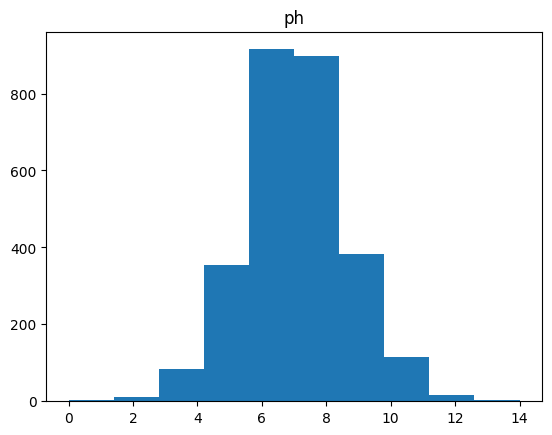

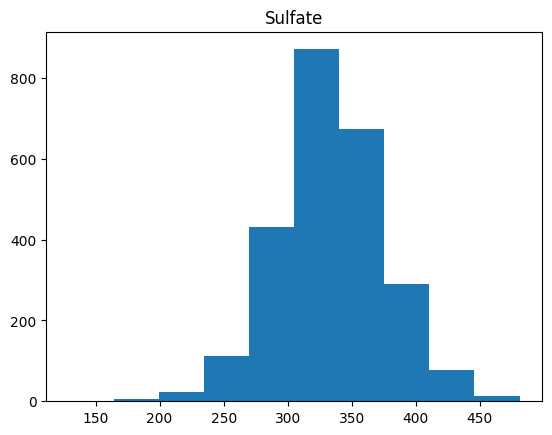

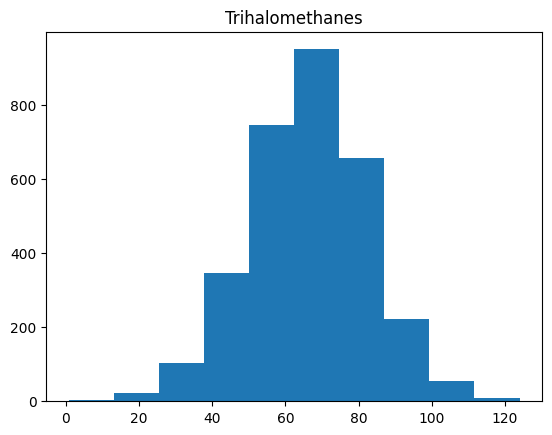

In [12]:
import matplotlib.pyplot as plt
missing_columns = ['ph', 'Sulfate', 'Trihalomethanes']
for column in missing_columns:
  plt.hist(water_dataset[column])
  plt.title(column)
  plt.show()

In [13]:
"""
replacing ph with mean since distribution is uniform and replacing Sulfate and
and Trihalomethanes wwitg median since distribution is skewed.
"""
water_dataset['ph'] = water_dataset['ph'].fillna(water_dataset['ph'].mean())
water_dataset['Sulfate'] = water_dataset['Sulfate'].fillna(water_dataset['Sulfate'].median())
water_dataset['Trihalomethanes'] = water_dataset['Trihalomethanes'].fillna(water_dataset['Trihalomethanes'].median())
water_dataset.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [14]:
water_dataset.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.608364,426.205111,14.284970,66.407478,3.966786,0.390110
std,1.469956,32.879761,8768.570828,1.583085,36.143851,80.824064,3.308162,15.769958,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.080795,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [35]:
import seaborn as sns
def box_plot(df):
  columns = df.drop('Potability', axis=1).columns
  cols = 3
  rows = (len(columns) + cols -1 ) // cols
  plt.figure(figsize=(cols*5, rows*4))
  for i, column in enumerate(columns):
      plt.subplot(rows, cols, i + 1)
      sns.boxplot(y=df[column])
      plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()


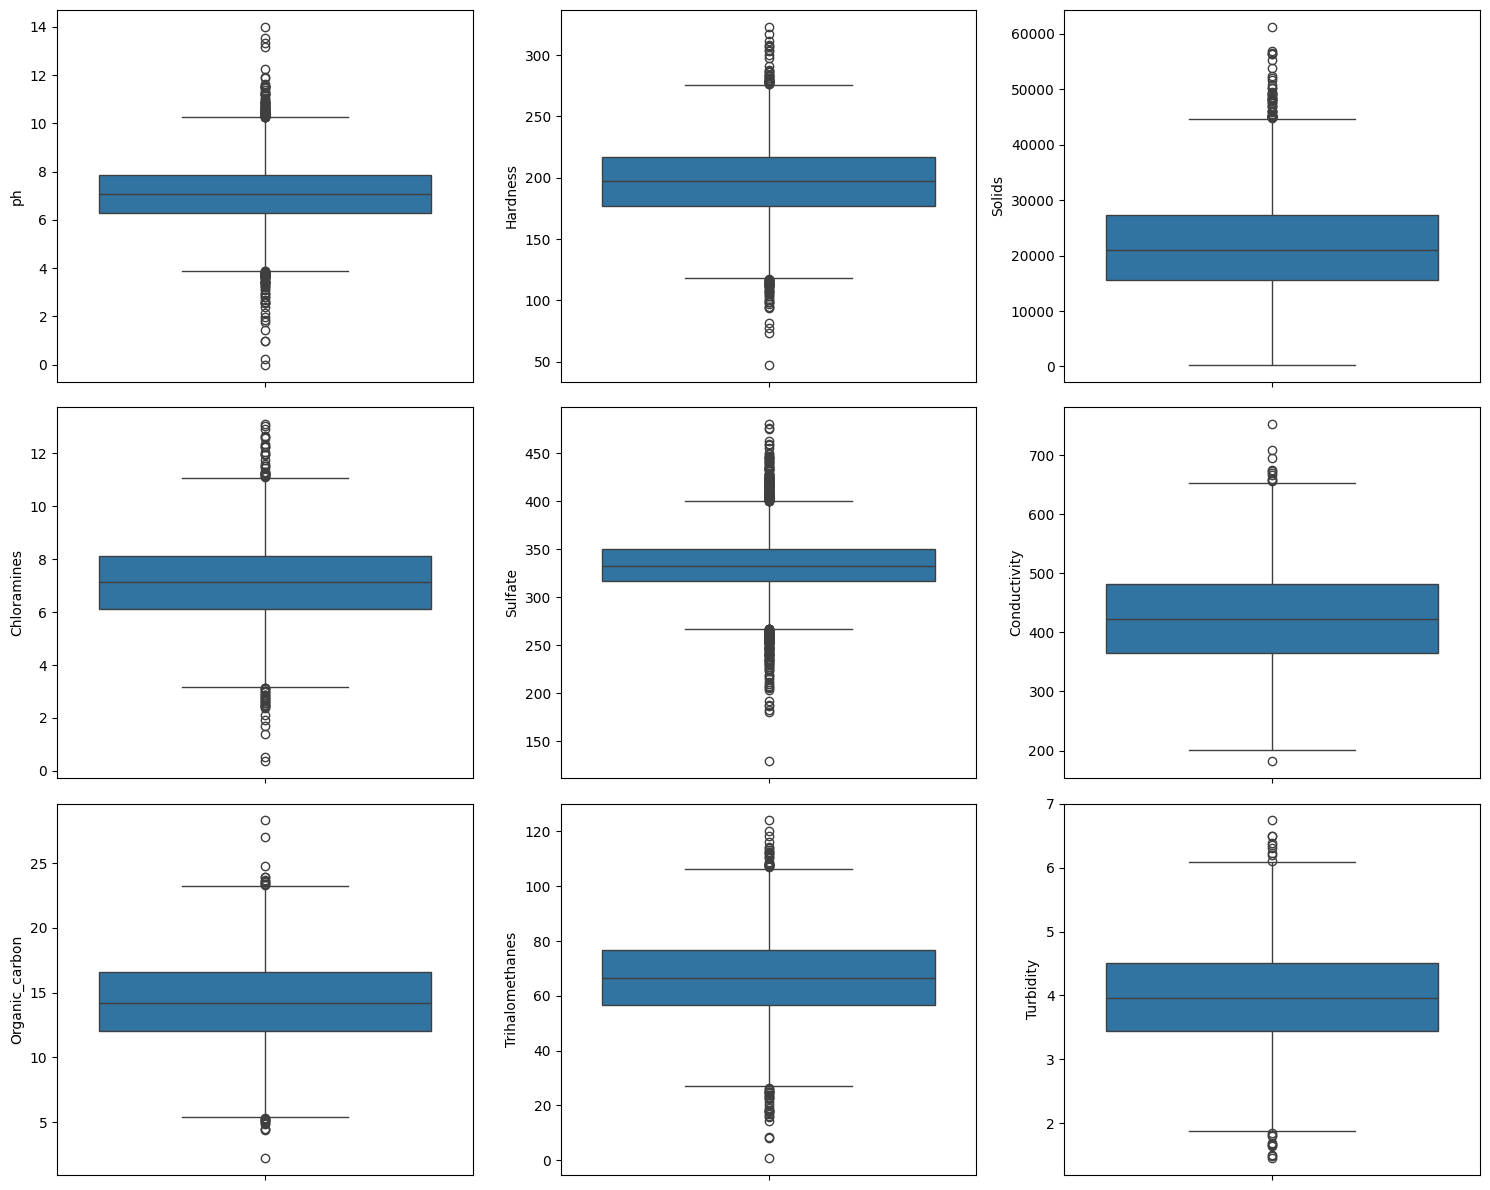

In [36]:
box_plot(water_dataset)

In [28]:
def handle_outliers_iqr(df, target_col=None):
    df_clean = df.copy()
    outlier_summary = {}

    for col in df.columns:
        if col == target_col:
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Count outliers before capping
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_summary[col] = outliers

        # Cap values
        df_clean[col] = df_clean[col].clip(lower, upper)

    print("Outliers detected per column (before capping):")
    for k, v in outlier_summary.items():
        print(f"{k}: {v}")

    return df_clean

In [29]:
water_clean = handle_outliers_iqr(water_dataset, target_col='Potability')

Outliers detected per column (before capping):
ph: 142
Hardness: 83
Solids: 47
Chloramines: 61
Sulfate: 264
Conductivity: 11
Organic_carbon: 25
Trihalomethanes: 54
Turbidity: 19


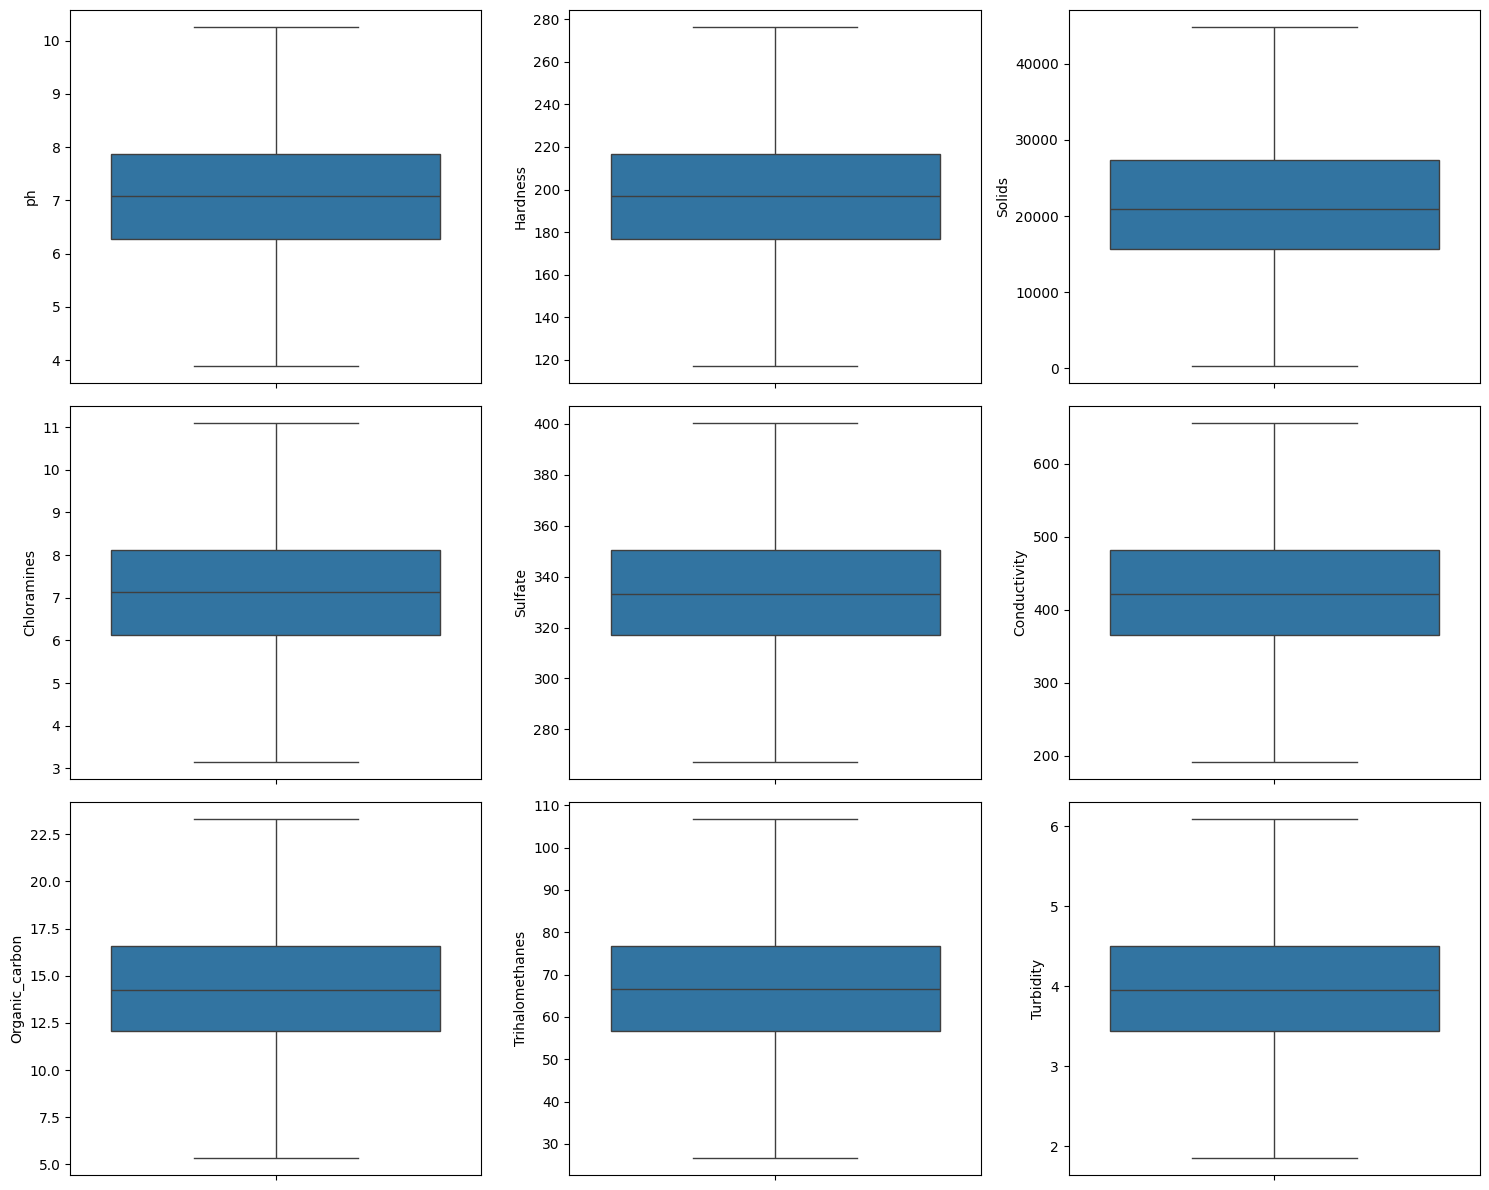

In [37]:
box_plot(water_clean)

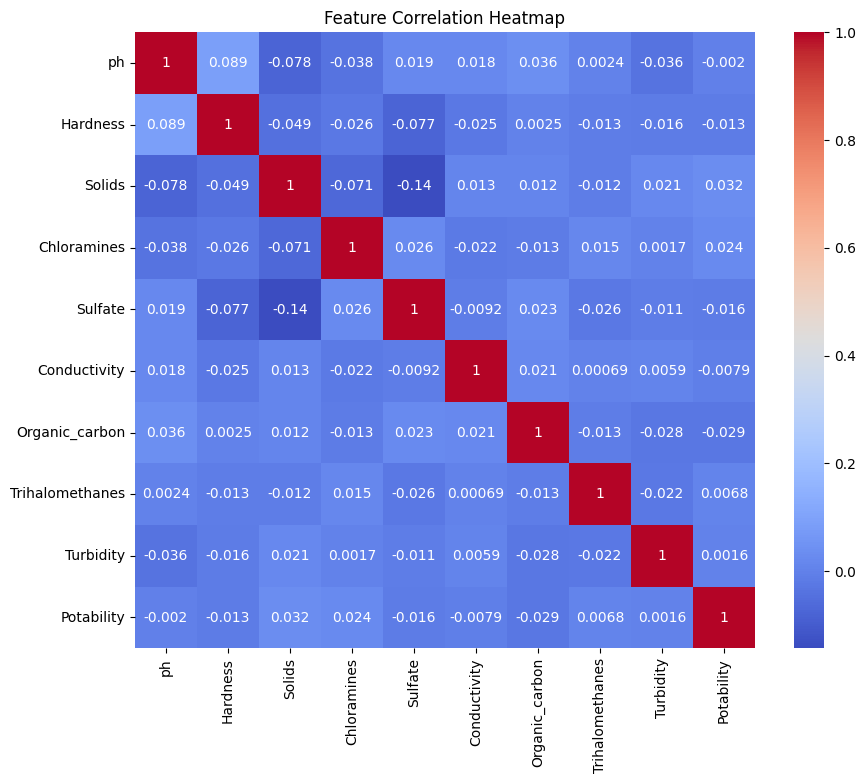

In [40]:
plt.figure(figsize=(10,8))
corr = water_clean.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

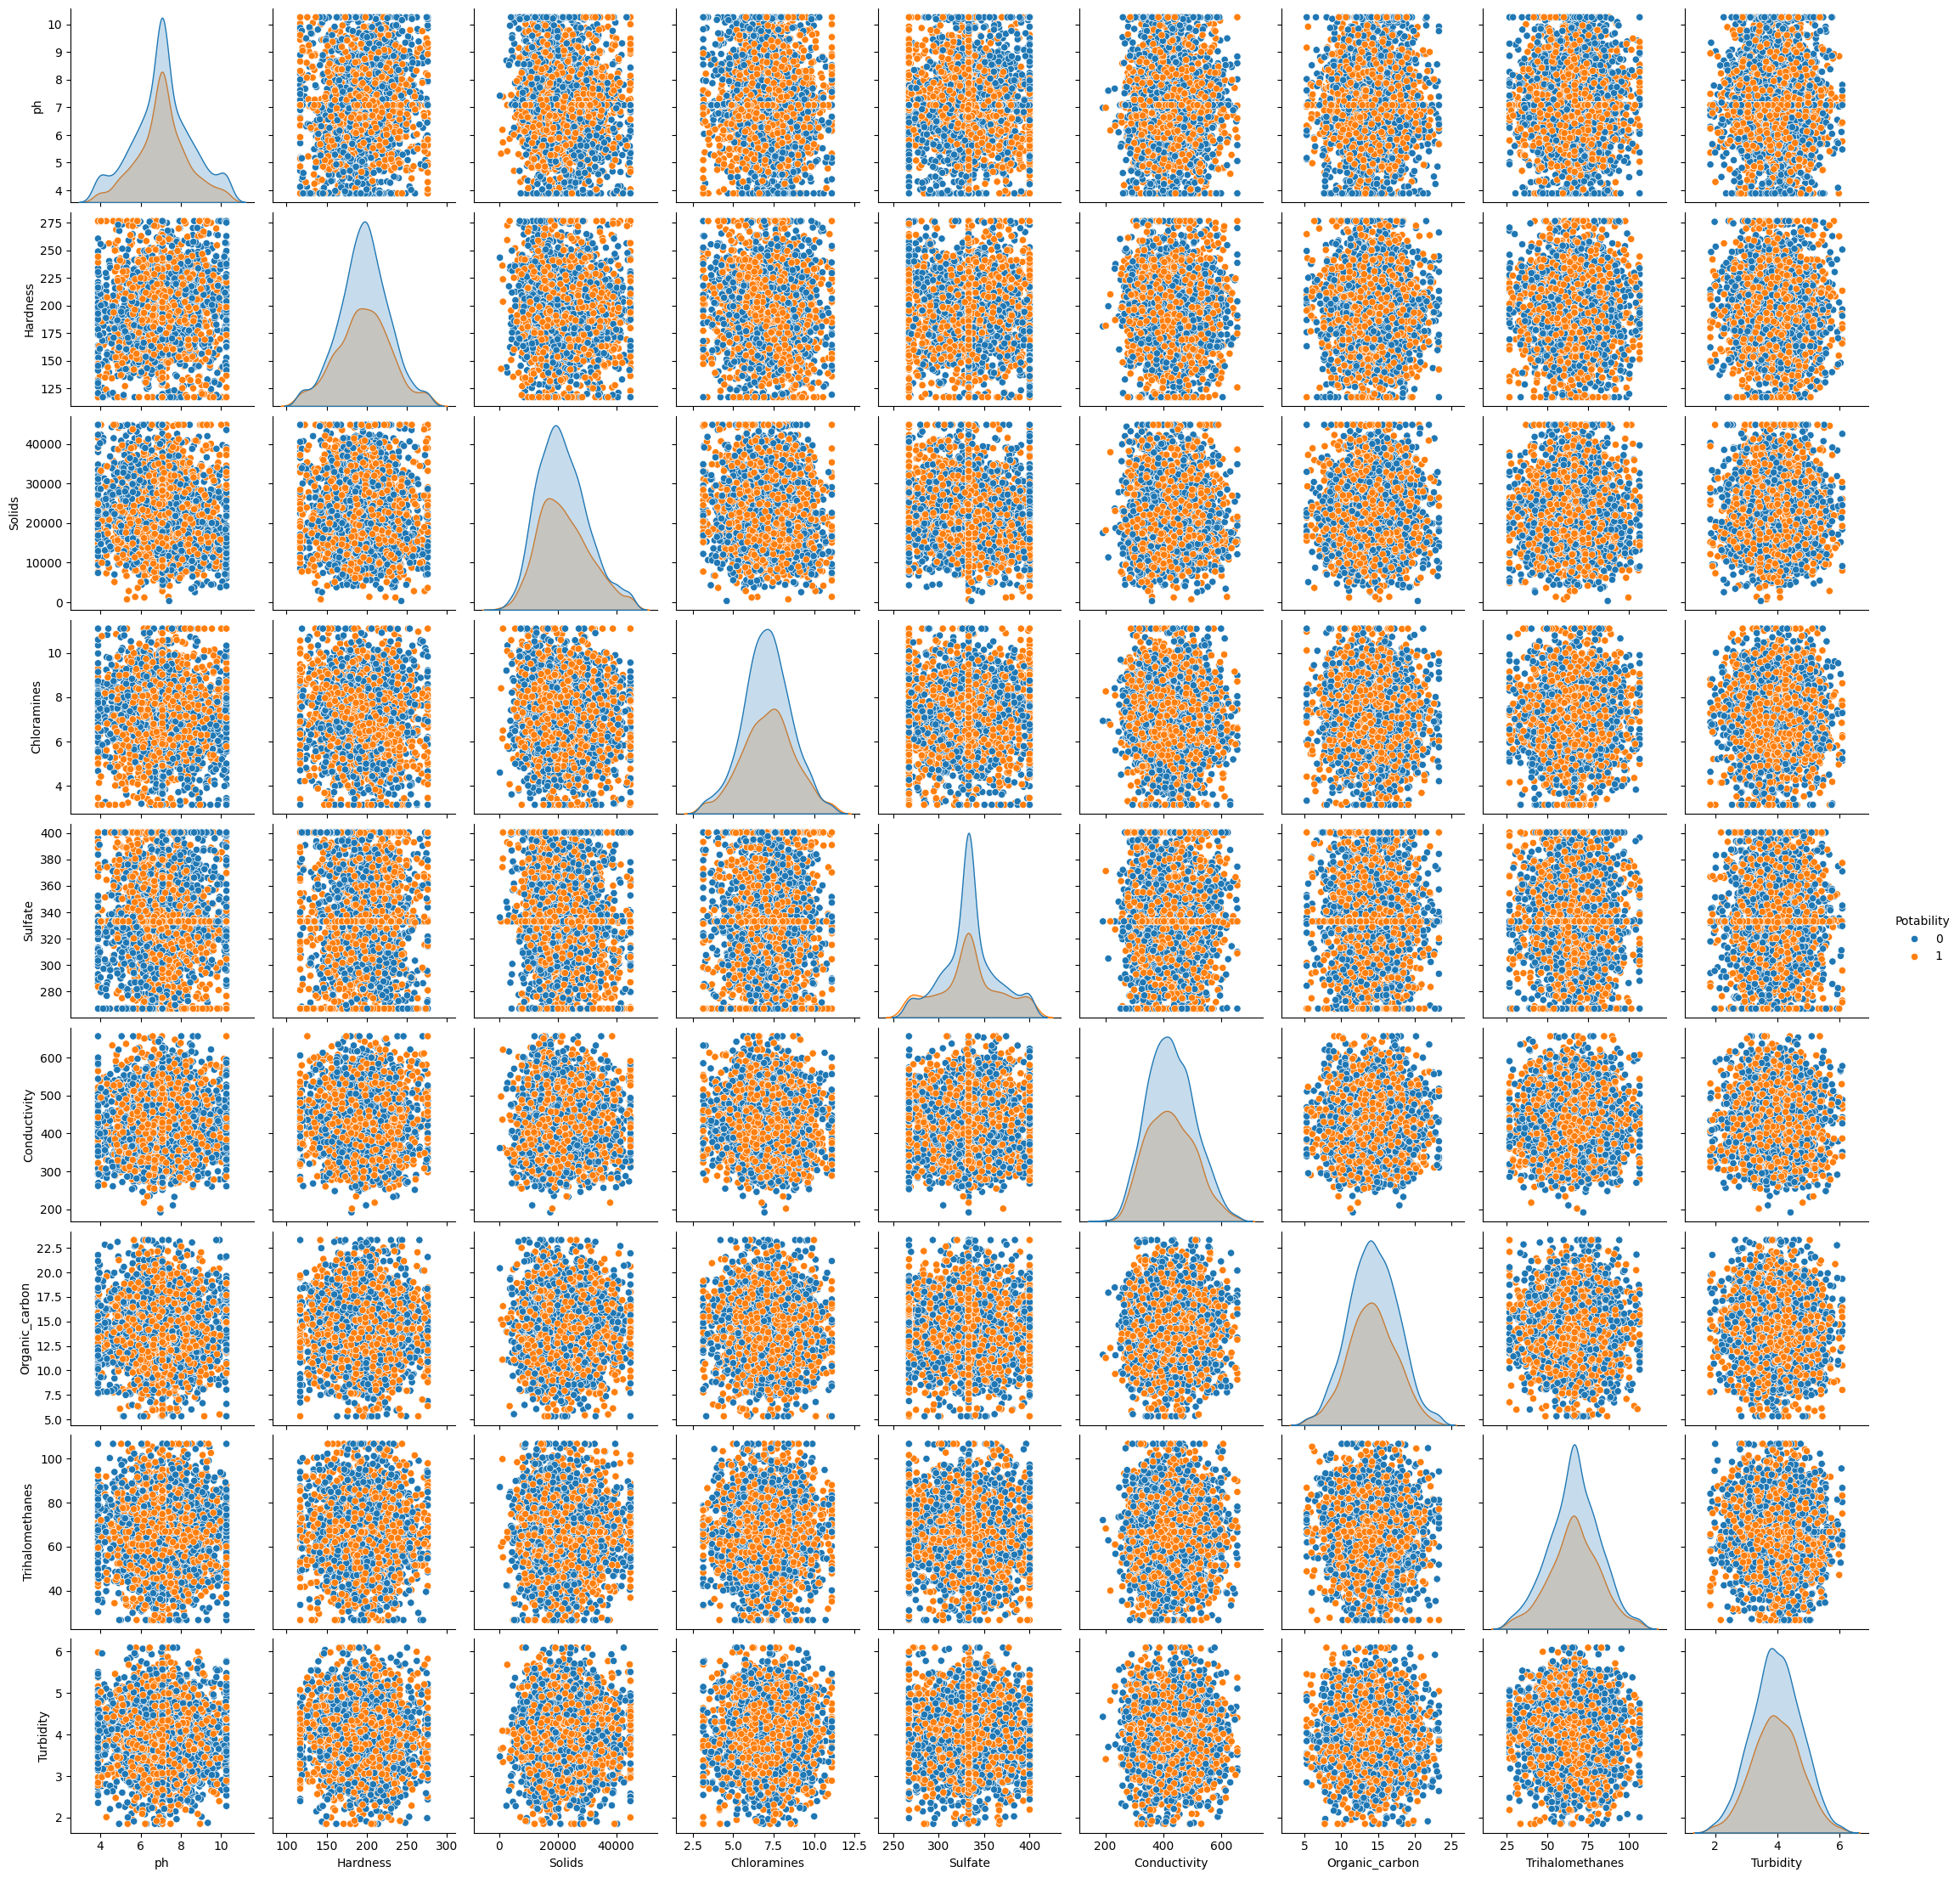

In [41]:
sns.pairplot(water_clean, hue="Potability")
plt.show()

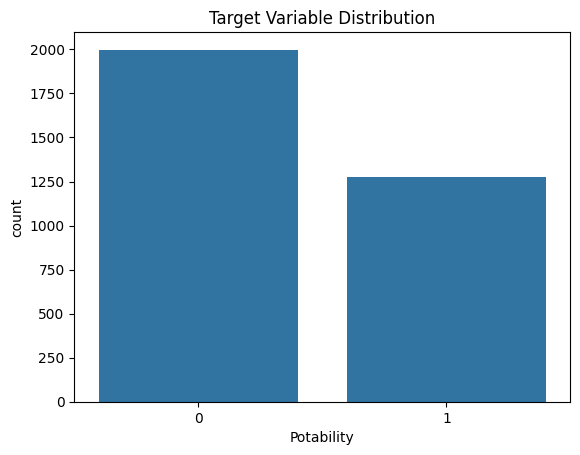

,proportion
Potability,
0,0.60989
1,0.39011


In [43]:
sns.countplot(x='Potability', data=water_clean)
plt.title("Target Variable Distribution")
plt.show()

water_dataset['Potability'].value_counts(normalize=True)

# Feature Engineering

In [50]:
X = water_clean.drop("Potability", axis=1)

X["solids_per_conductivity"] = X["Solids"] / (X["Conductivity"] + 1)
X["chloramine_sulfate_ratio"] = X["Chloramines"] / (X["Sulfate"] + 1)
X["organic_turbidity"] = X["Organic_carbon"] * X["Turbidity"]
X["ph_deviation"] = abs(X["ph"] - 7)

y = water_clean["Potability"]


# Data Preprocessing


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Modeling


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, recall_score

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
dt = DecisionTreeClassifier(random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
scaler = StandardScaler()

lr_pipeline = Pipeline([
    ("scaler", scaler),
    ("lr", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

knn_pipeline = Pipeline([
    ("scaler", scaler),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

svm_pipeline = Pipeline([
    ("scaler", scaler),
    ("svm", SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=42))
])
models = {
    "Logistic Regression": lr_pipeline,
    "KNN": knn_pipeline,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
    "SVM": svm_pipeline
}

In [62]:
model_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.45      0.53       400
           1       0.41      0.60      0.49       256

    accuracy                           0.51       656
   macro avg       0.53      0.53      0.51       656
weighted avg       0.55      0.51      0.51       656

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.78      0.70       400
           1       0.48      0.32      0.39       256

    accuracy                           0.60       656
   macro avg       0.56      0.55      0.54       656
weighted avg       0.58      0.60      0.58       656

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.62      0.63       400
           1       0.44      0.47      0.46       256

    accuracy                           0.56       656
   macro avg      


Model Performance Summary:

                     Accuracy %  ROC-AUC %  Recall (Class 1) %
Random Forest         66.006098  65.739258           27.343750
XGBoost               63.871951  64.591797           39.843750
SVM                   61.432927  63.705078           47.656250
KNN                   59.908537  59.117188           32.421875
Decision Tree         56.250000  54.632813           47.265625
Logistic Regression   51.067073  56.958008           60.156250


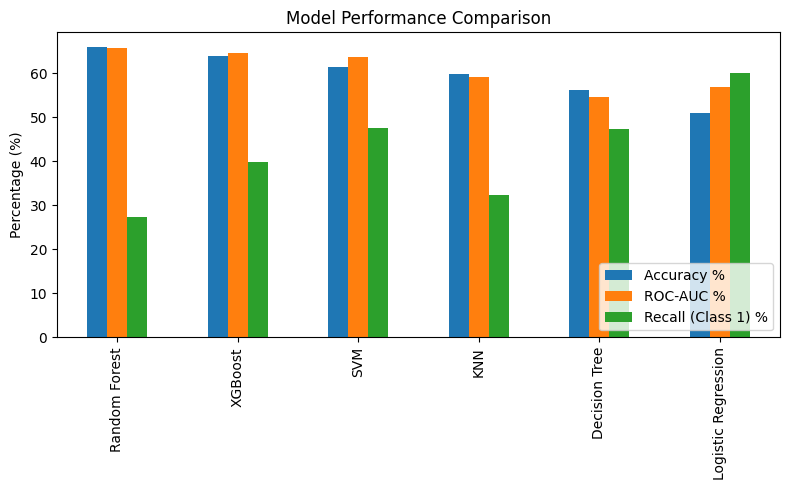

In [66]:
model_metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred) * 100

    # ROC-AUC: need probabilities
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    else:
        # for SVM or other classifiers with probability=True
        y_proba = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, y_proba) * 100

    # Recall for class 1 (potable water)
    recall1 = recall_score(y_test, y_pred, pos_label=1) * 100

    model_metrics[name] = {
        "Accuracy %": acc,
        "ROC-AUC %": roc,
        "Recall (Class 1) %": recall1
    }

results_df = pd.DataFrame(model_metrics).T.sort_values(by='Accuracy %', ascending=False)
print("\nModel Performance Summary:\n")
print(results_df)

results_df.plot(kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Percentage (%)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# Hypertuning

In [93]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_random.fit(X_train, y_train)
print("Best RF params:", rf_random.best_params_)
print("Best RF ROC-AUC (CV):", rf_random.best_score_)

best_rf = rf_random.best_estimator_

xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random.fit(X_train, y_train)
print("Best XGB params:", xgb_random.best_params_)
print("Best XGB ROC-AUC (CV):", xgb_random.best_score_)

best_xgb = xgb_random.best_estimator_


def evaluate_model(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    recall1 = recall_score(y_test, y_pred, pos_label=1)
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {acc:.4f}, ROC-AUC: {roc:.4f}, Recall (Class 1): {recall1:.4f}")
    return acc, roc, recall1


print("Random Forest Test Performance:")
rf_acc, rf_roc, rf_recall = evaluate_model(best_rf, X_test, y_test)

print("\nXGBoost Test Performance:")
xgb_acc, xgb_roc, xgb_recall = evaluate_model(best_xgb, X_test, y_test)



Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 15}
Best RF ROC-AUC (CV): 0.6709361483908496
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best XGB ROC-AUC (CV): 0.6774119875222816
Random Forest Test Performance:
              precision    recall  f1-score   support

           0       0.66      0.88      0.75       400
           1       0.61      0.30      0.40       256

    accuracy                           0.65       656
   macro avg       0.63      0.59      0.58       656
weighted avg       0.64      0.65      0.62       656

Accuracy: 0.6509, ROC-AUC: 0.6580, Recall (Class 1): 0.3008

XGBoost Test Performance:
              precision    recall  f1-score   support

           0       0.67      0.88      0.76       400
           1   

In [104]:
best_model = best_rf if rf_acc > xgb_acc else best_xgb
print(f"\nBest Model: {best_model_name}")


Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [106]:
import joblib
from google.colab import drive
drive.mount('/content/drive')
joblib.dump(best_model, "/content/drive/MyDrive/Aqua-Safe/aqua_safe_model.pkl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['/content/drive/MyDrive/Aqua-Safe/aqua_safe_model.pkl']